<a href="https://colab.research.google.com/github/BaharathBathula/quantum-fraud-detection-qiskit/blob/main/notebooks/quantum_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_aer import Aer

In [11]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

data = pd.read_csv(url)

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
X = data.drop("Class", axis=1)
y = data["Class"]

# Reduce features for quantum model
X = X.iloc[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

feature_map.draw()

/tmp/ipykernel_214/3302137348.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)


┌──────────────────────────┐
q_0: ┤0                         ├
     │  ZZFeatureMap(x[0],x[1]) │
q_1: ┤1                         ├
     └──────────────────────────┘

In [20]:
!pip install qiskit qiskit-aer qiskit-machine-learning

In [22]:
!pip install --upgrade qiskit qiskit-aer qiskit-machine-learning

In [32]:
from qiskit_aer import Aer
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_aer.primitives import Sampler # Import Sampler from qiskit_aer.primitives

# Define the backend
simulator_backend = Aer.get_backend("statevector_simulator")

# Instantiate a Sampler (without the backend argument in init)
aer_sampler = Sampler()

# Create the quantum kernel using the sampler
quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

In [34]:
backend = Aer.get_backend("statevector_simulator")

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

In [38]:
data = pd.read_csv(url)

# very small sample for demo
data = data.sample(n=30, random_state=42)

In [39]:
X = data.drop("Class", axis=1)
y = data["Class"]

# keep only 2 features for first quantum demo
X = X.iloc[:, :2]

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
from qiskit.circuit.library import ZZFeatureMap

feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
feature_map

/tmp/ipykernel_214/2717229934.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)


In [44]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

In [45]:
from sklearn.svm import SVC

svm = SVC(kernel=quantum_kernel.evaluate)
svm.fit(X_train, y_train)

SVC(kernel=<bound method FidelityQuantumKernel.evaluate of <qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x7c3bf88fbfb0>>)

In [46]:
from sklearn.metrics import accuracy_score, classification_report

predictions = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions, zero_division=0))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Classical SVM baseline
classical_svm = SVC(kernel="rbf")
classical_svm.fit(X_train, y_train)

classical_preds = classical_svm.predict(X_test)

print("Classical SVM Accuracy:", accuracy_score(y_test, classical_preds))
print(classification_report(y_test, classical_preds, zero_division=0))

Classical SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [49]:
from qiskit_machine_learning.algorithms import QSVC
from sklearn.metrics import accuracy_score, classification_report

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

quantum_preds = qsvc.predict(X_test)

print("Quantum QSVC Accuracy:", accuracy_score(y_test, quantum_preds))
print(classification_report(y_test, quantum_preds, zero_division=0))

Quantum QSVC Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [52]:
!pip install pylatexenc

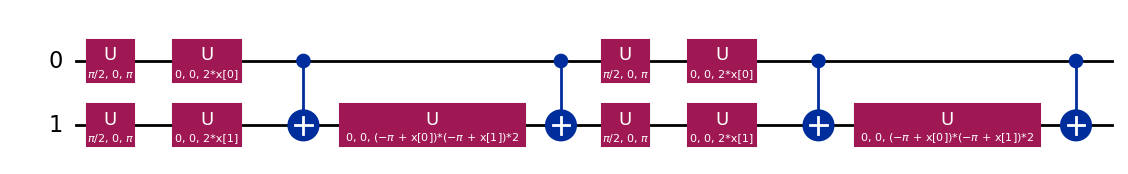

In [3]:
from qiskit.circuit.library import zz_feature_map # Import the function

# Use the function instead of the class
feature_map = zz_feature_map(feature_dimension=2, reps=2)
feature_map.decompose().draw("mpl")

In [4]:
print(feature_map)

   ┌───┐┌───────────┐                                          ┌───┐»
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐├───┤»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├┤ H ├»
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘└───┘»
«   ┌───────────┐                                          
«0: ┤ P(2*x[0]) ├──■────────────────────────────────────■──
«   ├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
«1: ┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
«   └───────────┘└───┘└──────────────────────────────┘└───┘


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# Load and sample data
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data = pd.read_csv(url)
data = data.sample(n=30, random_state=42)

# Prepare features and labels
X = data.drop("Class", axis=1)
y = data["Class"]
X = X.iloc[:, :2]

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define feature map and quantum kernel
feature_map = zz_feature_map(feature_dimension=2, reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# Classical SVM
classical_svm = SVC(kernel="rbf")
classical_svm.fit(X_train, y_train)
classical_preds = classical_svm.predict(X_test)

# Quantum QSVC
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)
quantum_preds = qsvc.predict(X_test)

print("Variables y_test, classical_preds, and quantum_preds are now defined.")

Variables y_test, classical_preds, and quantum_preds are now defined.


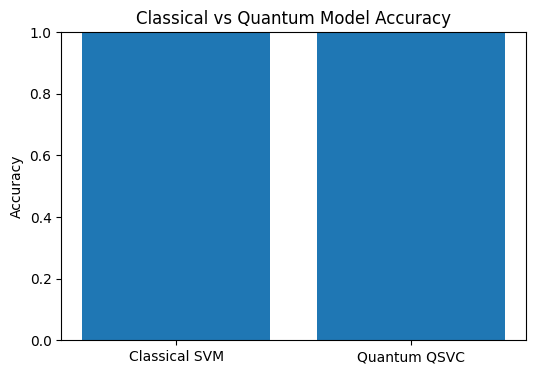

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

# Define results_df here to ensure it exists
classical_acc = accuracy_score(y_test, classical_preds)
quantum_acc = accuracy_score(y_test, quantum_preds)

results_df = pd.DataFrame({
    "Model": ["Classical SVM", "Quantum QSVC"],
    "Accuracy": [classical_acc, quantum_acc]
})

plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Classical vs Quantum Model Accuracy")
plt.ylim(0, 1)
plt.show()

In [9]:
results_df.to_csv("model_comparison.csv", index=False)
print("Saved model_comparison.csv")

Saved model_comparison.csv


# Quantum Fraud Detection using Qiskit

This notebook demonstrates a hybrid quantum-classical workflow for fraud detection using:

- ZZFeatureMap for quantum feature encoding
- FidelityQuantumKernel for similarity computation
- QSVC for quantum classification
- Classical SVM as a baseline comparison

Because quantum kernel evaluation is computationally expensive, a small balanced sample is used for demonstration.